# Clean file with modules

In [1]:
import sys
import os

parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(parent_dir)
parent_dir1 = os.path.abspath(os.path.join(parent_dir, '..'))
sys.path.append(parent_dir1)

import pytorch_lightning as pl
from pytorch_lightning.loggers import WandbLogger
from torch import nn
import torch.nn.functional as F
from simspice.data.SproutDataset import SproutDataset
from torch.utils.data import DataLoader
from pytorch_lightning.callbacks import ModelCheckpoint
import torch
import numpy as np
import matplotlib.pyplot as plt
from cuml.cluster.hdbscan import HDBSCAN

import matplotlib.pyplot as plt
from lightly.loss import NTXentLoss

import simspice.utils.inverse_mapping_functions as imf
import simspice.models.VICReg_Architecture as SA
import wandb
#import umap.umap_ as umap
import tqdm
from datetime import datetime

plt.rcParams['image.origin'] = 'lower'

BATCH_SIZE = 128

In [2]:
simspice = "/d0/tvaresano/SimSPICE/"

In [3]:
os.environ["CUDA_VISIBLE_DEVICES"] = "2"

In [4]:
dataset_path = simspice+"spectra_Feb2023.nc"
dataset = SproutDataset(
    dataset_path=simspice + "spectra_Feb2023.nc",
    augmentation_type="double",
    csv_files=simspice + "L2_names.csv",
    log_space=False,
    normalize_intensity=True,
    sigma_shift=0.1,
    sigma_gain=0.1,
    gain_range=(0.8, 1.2),
    type_distrib_gain="uniform",
)

dataloader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

## Train model

In [5]:
id = 'CNN_VICReg_updated'

In [ ]:
epoch_nbr = 5
model = SA.SpectralVICReg(
    backbone_embedding_dim=256,
    projection_hidden_dim=512,
    projection_output_dim=128,
    learning_rate=3e-4,
    weight_decay=1e-4,
    maximum_epochs=epoch_nbr,
    invariance_weight=25.0,
    variance_weight=25.0,
    covariance_weight=1.0)

accelerator = "gpu" if torch.cuda.is_available() else "cpu"

wandb_logger = WandbLogger(project="runs_double_augmentation", name=f"{id}_{datetime.today().strftime('%Y-%m-%d')}", log_model=True)

trainer = pl.Trainer(max_epochs=epoch_nbr, devices=1, accelerator=accelerator, logger=wandb_logger)
trainer.fit(model=model, train_dataloaders=dataloader)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA A100 80GB PCIe') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
wandb: Currently logged in as: tava8993 (tava8993-boulder) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [2]

  | Name            | Type                   | Params | Mode 
-------------------------------------------------------------------
0 | backbone        | SpectralCNNTransformer | 817 K  | train
1 | projection_head | VICRegProjectionHead   | 460 K  | train
2 | criterion       | VICRegLoss             | 0      | train
-------------------------------------------------------------------
1.3 M     Trainable params
0         Non-trainable params
1.3 M     Total params
5.113     Total estimated model params size (MB)
90        Modules in train mode
0         Modules in eval mode


Epoch 4: 100%|██████████| 907/907 [04:06<00:00,  3.68it/s, v_num=g42t, train_loss_step=4.310, train_loss_epoch=4.290]

`Trainer.fit` stopped: `max_epochs=5` reached.


Epoch 4: 100%|██████████| 907/907 [04:06<00:00,  3.68it/s, v_num=g42t, train_loss_step=4.310, train_loss_epoch=4.290]


## If loading from previous checkpoint

In [ ]:
# checkpoint = simspice+"\\notebooks\\FullDataset_64_doubleAug_normalized_spec\\k81c85sl\\checkpoints\\epoch=4-step=9075.ckpt"
# model = SA.SimSiam.load_from_checkpoint(checkpoint)  # Continue epochs

# accelerator = "gpu" if torch.cuda.is_available() else "cpu"
# wandb_logger = WandbLogger(project="FullDataset_64_doubleAug_normalized_spec", log_model=True)
# trainer = pl.Trainer(max_epochs=10, devices=1, accelerator=accelerator, logger=wandb_logger)
# trainer.fit(model=model, train_dataloaders=dataloader)

-------------------------------------------------------------------

In [8]:
dataset_path = simspice + "/spectra_Feb2023.nc"

dataset_none = SproutDataset(dataset_path=dataset_path,
    augmentation_type=None, csv_files=simspice + "L2_names.csv",
    log_space=False, normalize_intensity=True,)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)
model.eval()

outputs = []

with torch.no_grad():
    for i in tqdm.tqdm(range(len(dataset_none))):
        spec = dataset_none[i].unsqueeze(0).to(device)

        embedding = model.encode(spec)

        outputs.append(embedding.squeeze(0).cpu().numpy() )

stacked_outputs = np.stack(outputs, axis=0)
print(stacked_outputs.shape)

100%|██████████| 116160/116160 [05:05<00:00, 380.72it/s]


(116160, 256)


In [ ]:
# checkpoint = "C:\\Users\\tania\Documents\CU Boulder\CU Alpine\models_ckpts\single_epoch=4-step=45750.ckpt"
# dataset_none = SproutDataset(dataset_path=dataset_path, augmentation_type=None)
# outputs = SA.run_model(checkpoint, dataset_none)

In [9]:
stacked_outputs = np.stack(outputs).squeeze()
stacked_outputs.shape
np.save(simspice+f'notebooks/jobs/model_outputs/stacked_outputs_single_Feb23_{id}.npy', stacked_outputs)

In [10]:
stacked_outputs = np.load(simspice+f'notebooks/jobs/model_outputs/stacked_outputs_single_Feb23_{id}.npy')

## Clustering

In [17]:
xs = [30,50,100]
ys = [15,25,40]

In [ ]:
for x in xs:
    for y in tqdm.tqdm(ys):
        clusterer = HDBSCAN(min_cluster_size=x, min_samples=y, metric='euclidean') # <=> cosine?
        clusterer.fit(stacked_outputs)
        labels = clusterer.labels_
        np.save(simspice+f'notebooks/jobs/clustering_outputs/minclus{x}_minsamp{y}.npy', labels)

100%|██████████| 3/3 [00:15<00:00,  5.20s/it]


Text(0.5, 0.98, 'Feb23_Fulltrained_single32')

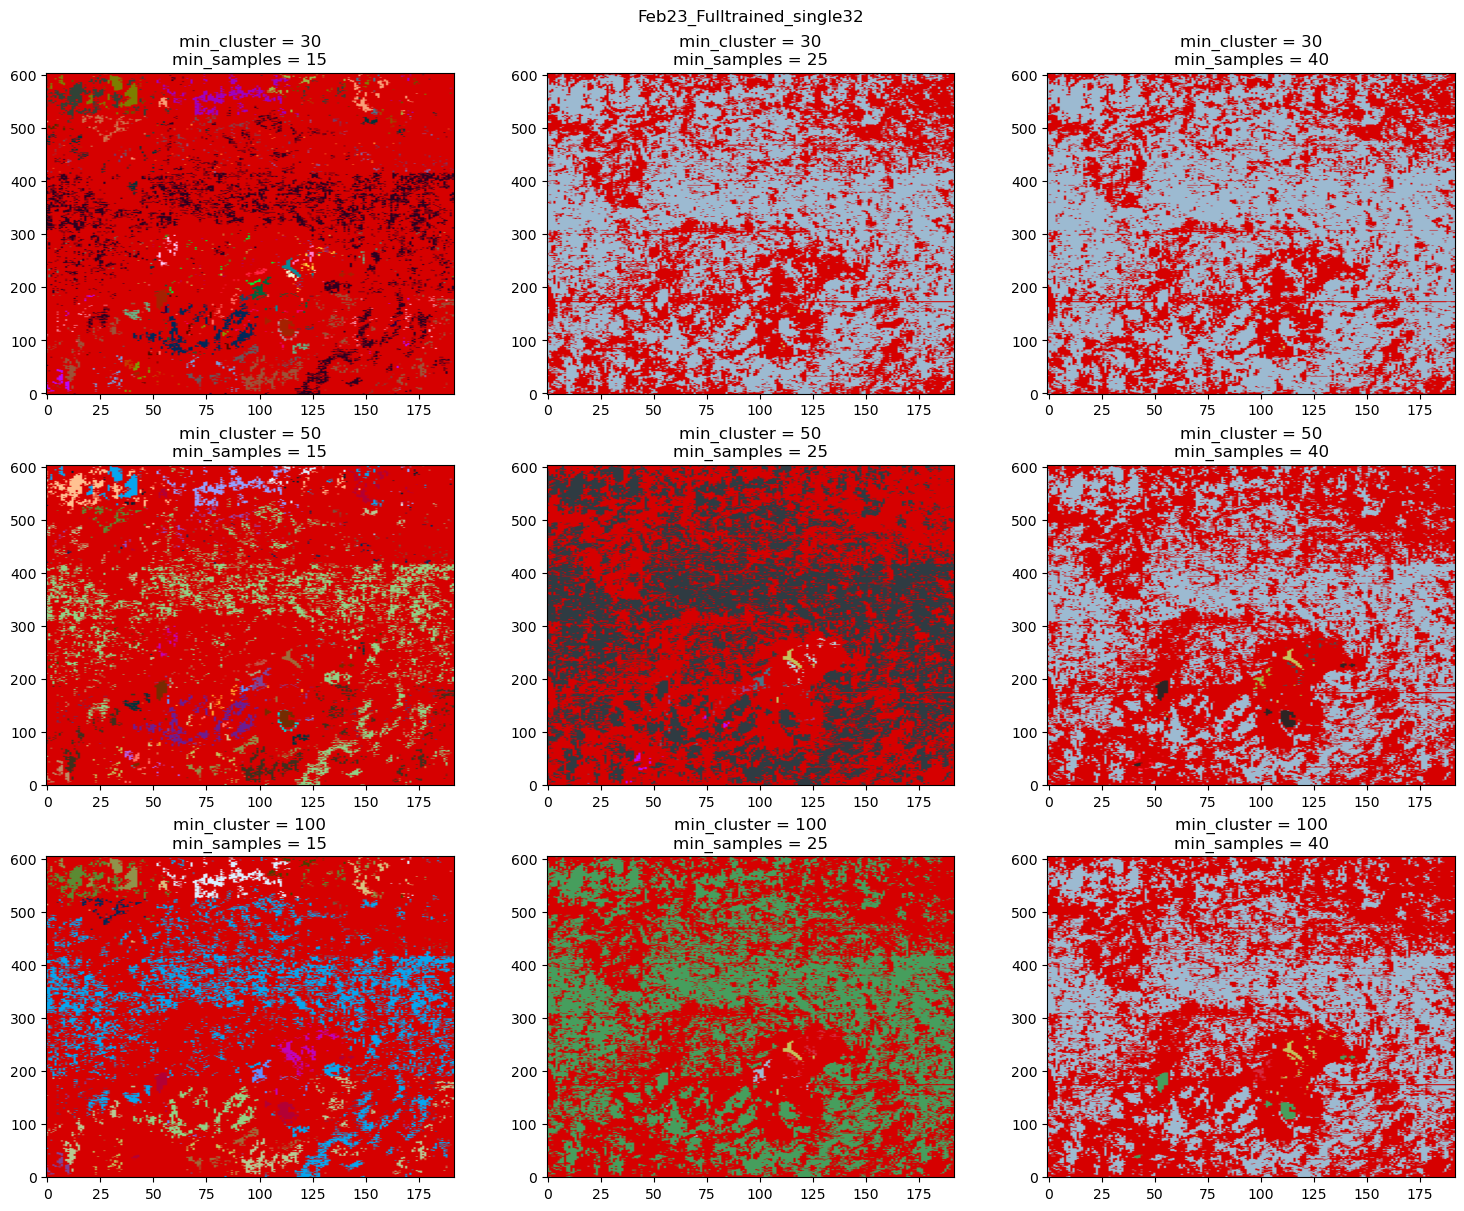

In [18]:
c=0
fig, axes = plt.subplots(3, 3, figsize=(15, 12), constrained_layout=True)
for ax, x, y in zip(axes.flat, np.repeat(xs, 3), np.tile(ys, 3)):
        c+=1
        labels = np.load(simspice+f'notebooks/jobs/clustering_outputs/minclus{x}_minsamp{y}.npy')
        imf.map_clusters(labels, dataset_path=simspice+'spectra_Feb2023.nc', selected_clusters=None, ax=ax)
        ax.set_title(f"min_cluster = {x}\nmin_samples = {y}")
fig.suptitle('Feb23_Fulltrained_single32')